Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.0158 - loss: 3.9116 - val_accuracy: 0.0133 - val_loss: 3.9116
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0233 - loss: 3.9080 - val_accuracy: 0.0117 - val_loss: 3.9112
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0229 - loss: 3.9025 - val_accuracy: 0.0117 - val_loss: 3.9130
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0229 - loss: 3.8953 - val_accuracy: 0.0083 - val_loss: 3.9193
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0254 - loss: 3.8888 - val_accuracy: 0.0200 - val_loss: 3.9142


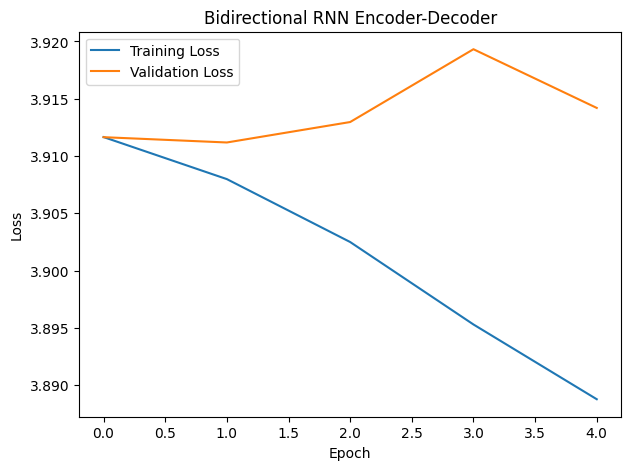

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
Input Sequence:
[39 29 15 43  8 21]
Predicted Output Sequence:
[49 49 49 49 41 41]


In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense

np.random.seed(42)
tf.random.set_seed(42)

input_vocab = 50
output_vocab = 50
sequence_length = 6
embedding_dim = 32
hidden_units = 64
num_samples = 500

X = np.random.randint(
    1,
    input_vocab,
    (num_samples, sequence_length)
)

Y = np.random.randint(
    1,
    output_vocab,
    (num_samples, sequence_length)
)

encoder_inputs = Input(
    shape=(sequence_length,)
)

encoder_embedding = Embedding(
    input_vocab,
    embedding_dim
)(encoder_inputs)

encoder_output = Bidirectional(
    LSTM(
        hidden_units,
        return_sequences=True
    )
)(encoder_embedding)

decoder_output = LSTM(
    hidden_units,
    return_sequences=True
)(encoder_output)

outputs = Dense(
    output_vocab,
    activation="softmax"
)(decoder_output)

model = Model(
    encoder_inputs,
    outputs
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X,
    Y,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

plt.figure(figsize=(7, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Bidirectional RNN Encoder-Decoder")
plt.legend()
plt.show()

sample = X[:1]

prediction = model.predict(sample)

predicted_sequence = np.argmax(
    prediction,
    axis=-1
)

print("Input Sequence:")
print(sample[0])

print("Predicted Output Sequence:")
print(predicted_sequence[0])